# TAREA SEAMANAL 3

<div style="display: flex; justify-content: center; margin-top: 10px;">
  <img src="images/logo_utnba.png" width="500">
</div>


**<p style="font-size:20px;">Filtro tipo Chebyshev analisis y diseño a partir de una plantilla</p>**

![plantilla](images/plantilla.png)

## 1.) Obtener la transferencia mediante aproximación de chebyshev del filtro requerido

Para obtenter la aproximación de chebyshev y cumplir con la plantilla propuesta, en primera instancia verificamos que tipo de filtro es. En nuestro caso se observa que para antes de $f_s$ la zona prohibida la tiene abajo de $\alpha_{min}$, esto nos indica que es un filtro tipo pasa altos por lo que una vez que sabemos el filtro lo que haces es pasa mi plantilla objetivo a una plantilla de pasa bajos.

Primeramente normalizamos el eje de frecuencias respecto a $f_p$ para que de esta manera el $f_p$ nos quede "centrado" en 1 y lo demas este acorde a esa frecuencia normalizada.

Imagen... de como queda normalizado

Una vez que se tiene la plantilla objetivo (pasa altos) ya normalizada a $f_p$ realizamos un mapeo inverso, para obtener una plantilla prototipo (pasa bajos) donde para pasar de un pasa bajos a pasa altos reemplazamos de la siguiente manera: $f(\Omega) = 1/\omega$ de esta manera obtendremos la plantailla prototipo (pasa bajos) y operaremos para obtener el filtro chebyshev que cumpla con la plantilla requerida.

Imagen... de como queda filtro prototipo

Recordando algunas cuestiones de un filtro chebyshev vistos en la teoria recordamos lo siguiente:

$$\epsilon^2 = 10^{0.1 \cdot \alpha_{max,dB}} - 1$$

$$\alpha_{min}=10 \cdot log_{10}(1 + \epsilon^2 \cdot cosh(n\cdot cosh^{-1}(\omega_s))^2)$$

$$|T_c(\omega)|^2 = \frac{1}{1 + \epsilon^2 \cdot C_n(\omega)^2} =T(s) \cdot T(-s)$$

$$C_n(\omega) = 2\omega\cdot C_{n-1}(\omega) - C_{n-2}(\omega)$$

$$C_1(\omega)=\omega --y-- C_0(\omega)=1$$

De aca se puede obtener facilmente el $\epsilon^2$ ya que tenemos el $\alpha_{min}$ y simplemente reemplazamos para para obtener su valor

$$\epsilon^2 = 10^{0.1 \cdot 0.5 dB} - 1 \Rightarrow \boxed{\epsilon^2 = 0.122}$$

Una vez que tenemos el $\epsilon^2$ podemos obtener el $n$ con la expresion de $\alpha_{min}$ pero encontrar el n se complica ya que tendriamos que despejar mucho y es una ecuación un poco complicada de despejar, por lo que para obtener el n que necesitamos hacemos una iteración hasta obtener por lo menos $\alpha_{min}$.

$$n=2 \Rightarrow \alpha_{min} = 20.73 db$$

$$n=3 \Rightarrow \alpha_{min} = 38.61 db$$

$$n=4 \Rightarrow \alpha_{min} = 56.53 db$$

se puede observar que para $\boxed{n=3}$ ya se obtiene el $\alpha_{min}$ necesario por lo que nuestro filtro nos queda de un orden 3, por lo que una vez que obtenemos el n, empezamos a obtener la ecuacion a partir de los $C_n(\omega)$

$$n=2 \Rightarrow C_2(\omega)=2\omega \cdot C_1(\omega) - C_0(\omega)$$

$$C_2(\omega) = 2\omega \cdot \omega - 1$$

$$C_2(\omega) = 2\omega^2 - 1$$

$$n=3 \Rightarrow C_3(\omega)=2\omega \cdot C_2(\omega) - C_1(\omega)$$

$$C_3(\omega) = 2\omega \cdot (2 \omega^2 - 1) - \omega$$

$$\boxed{C_3(\omega) = 4 \omega^3 - 3 \omega}$$

Bueno una vez obtenido se reemplaza en la ecuacion de T(w)

$$|T(\omega)|^2 = \frac{1}{1 + \epsilon^2 \cdot (4 \omega^3 - 3 \omega)^2}$$

$$|T(\omega)|^2 = \frac{1}{16\epsilon^2 \cdot \omega^6 - 24\epsilon^2 \cdot \omega^4  + 9\epsilon^2 \cdot \omega^2 + 1}$$

$$|T(\omega)|^2 |_{w=s/j} = T(s) \cdot T(-s) = \frac{1}{-16\epsilon^2 \cdot s^6 - 24\epsilon^2 \cdot s^4  - 9\epsilon^2 \cdot s^2 + 1}$$

Resolviendo y separando en T(s) y T(-s) obtengo la siguiente expresion para T(s)

$$T(s) = \frac{1}{s^3 \cdot 1.40 + s^2 \cdot 1.75 + s \cdot 2.14 + 1}$$

$$\boxed{T(s) = \frac{0.71}{s^3 + s^2 \cdot 1.25 + s \cdot 1.53 + 0.71}}$$

Y tratando de separa el polinomio en una de orden y una de orden 1, es decir:

$$T(s) = \frac{k}{(s+a)(s^2+bs+c)}$$

Realizando reemplazos y cuestion algebraica obtengo el siguiente resultado

$$\boxed{T(s) = \frac{1}{s+0.62} \cdot \frac{0.71}{s^2 + s \cdot 0.62 + 1.15}}$$

Filtro pasa bajos de orden 3 tipo chebyshev

Una vez que obtuvimos el filtro prototipo chebyshev de orden 3 procedemos a realizar el mapeo para obtener mi filtro pasa altos, es decir, reemplazo $=1/S.

$$ T(s)|_{S=1/s} = \frac{s}{1 + s \cdot 0.62} \cdot \frac{s^2 \cdot 0.71}{s^2 \cdot 1.15 + s \cdot 0.62 + 1} $$

$$\boxed{T(s) = \frac{s \cdot 1.61}{ s + 1.61} \cdot \frac{s^2 \cdot 0.62}{s^2 + s \cdot 0.54 + 0.87}}$$

## 2.) Obtener la respuesta en frecuencia (modulo y fase) de forma cualitativa. Compare además el pzmap con el del filtro pasa bajos prototipo

![modulo a mano](images/2_modulo.png)

![fase a mano](images/2_fase.png)


## 3.) Implementar el circuito normalizado con estructuras pasivas utilizando dispositivos activos para separar secciones


$$T(s) = \frac{s \cdot 1.61}{ s + 1.61} \cdot \frac{s^2 \cdot 0.62}{s^2 + s \cdot 0.54 + 0.87}$$

$$T(s) = \frac{s \cdot 0.9982}{ s + 1.61} \cdot \frac{s^2}{s^2 + s \cdot 0.54 + 0.87}$$

$$T(s) = \frac{s}{ s + 1.61} \cdot \frac{s^2}{s^2 + s \cdot 0.54 + 0.87}$$

Bien una vez que tenemos el filtro pasa altos y tambien lo tenemos separado en 2 secciones una de orden 2 y otra de orden por lo que se puede plantear para el de orden 2 simplemente un RC y para el de orden 3 un RLC con un inductor.

SECCION 1 (orden 1)

![seccion 1](images/3_seccion1.png)

$$T_1(s) = \frac{\frac{1}{RC}}{s + \frac{1}{RC}}$$

Y sabiendo que me tiene que quedar como lo siguiente:

$$\frac{s}{ s + 1.61}$$

Igualo ambas ecuaciones y obtengo las siguientes igualdades

$$\frac{1}{RC} = 1.61$$

si considero al capacitor como $\boxed{C=1}$ me queda lo siguiente:

$$\frac{1}{R} = 1.61 \Rightarrow R = \frac{1}{1.61} \Rightarrow \boxed{R = 0.62}$$

SECCION 2 (orden 2)

![seccion 2](images/3_seccion2.png)

$$T_2(s) = \frac{s^2}{s^2 + s \cdot \frac{R}{L} + \frac{1}{LC}}$$

y yo se que me tiene que quedar de la siguiente manera:

$$T_2(s) = \frac{s^2}{s^2 + s \cdot 0.54 + 0.87}$$

Entonces igualando valores nos tiene que quedar de la siguiente manera:

$$\frac{1}{LC} = 0.87$$

$$\frac{R}{L} = 0.54$$

y si considero a $\boxed{L=1}$ entonces nos resume mas quedando de la siguiente manera:

$$\frac{1}{C} = 0.87 \Rightarrow \boxed{1.15}$$

$$\boxed{R = 0.54}$$

Una vez teniendo los dos filtros ya construidos se los pone en cascada con un adaptador de impedancias y se obtiene el filtro deseado quedando de la siguiente manera y obteniendo los siguientes resultados.

![circuito total](images/3_circuitoCompleto.png)

![Circuito completo grafico](images/3_circuitoCompletoGrafico.png)

## 4.) Reemplace los inductores en las estructuras pasivas mediante el GIC de Antoniou, en la configuración que considere más apropiada.


![gic de antonium](images/4_gic.png)


Bueno el GIC de antoniu es una configuracion donde se puede simular componentes a partir de ciertos parametros, la ecuacion que queda para el diseño de cualquier componente nos queda de la siguiente manera:

$$Z_{in} = \frac{Z_1 \cdot Z_3 \cdot Z_5}{Z_2 \cdot Z_4}$$

Para mi caso que quisiera que me funcione como un inductor me tiene que quedar como la forma de un inductor que es $Z_{indcutor} = S\cdot L$ por lo que ajusto los valores de $Z$ con capacitores y resistencias para obtener el $Z$ deseado

Tomo la siguiente configuracion: $Z_1 = Z_3 = Z_4 = Z_5 = R$ y $Z_2 = \frac{1}{S \cdot C}$

$$Z_{in} = \frac{R \cdot R \cdot R}{\frac{1}{SC} \cdot R}  \Rightarrow \boxed{Z_{in}=S\cdot R^2 \cdot C }$$

Bueno una vez obtenido la expresion de la impedancia esta se debe de igual a la inductancia que se obtuvo del punto anterior que en nuestro caso es de $L=1$ por lo que se tiene lo siguiente:

$$1 = R^2 \cdot C$$

y si considero que mi resistencia es de $\boxed{R=1}$ entonces mi capacitor tambien sera de $\boxed{C=1}$


![Circuito completo L](images/4_circuitoCompleto.png)


![Circuito completo L grafico](images/4_circuitoCompletoGrafico.png)

## 5.) Reemplace la SOS pasiva del punto 3. por la estructura MFB en configuración pasa altos y realice el estudio de sensibilidad de $S^{C_1}_{w0}$, $S^{R_1}_{w0}$, $S^{R_2}_{w0}$

![circuito MFB](images/5_MFB.png)

$$H(s) = \frac{-\frac{C_3}{C_1} \cdot s}{s^2 + s \frac{1}{R_2}(\frac{1}{C_2} + \frac{1}{C_1} + \frac{C_3}{C_2 \cdot C_1}) + \frac{1}{R_1\cdot R_2\cdot C_1\cdot C_2}}$$

Tambien se que la transferencia SOS me tiene que quedar de la siguiente manera:

$$T_2(s) = \frac{s^2}{s^2 + s \cdot 0.54 + 0.87}$$

Y igualando valores me queda de la siguiente manera:

$$\frac{1}{R_1\cdot R_2\cdot C_1\cdot C_2} = 0.87$$

$$\frac{1}{R_2}(\frac{1}{C_2} + \frac{1}{C_1} + \frac{C_3}{C_2 \cdot C_1}) = 0.54$$

$$\frac{C_3}{C_1} = 1$$

Entonces si tomo a $\boxed{C_1 = 1}$ tambien me queda que $\boxed{C_3 = 1}$ teniendo estos 2 valores las siguientes ecuaciones nos quedan de la siguiente manera:

$$\frac{1}{R_2}(\frac{2}{C_2} + 1) = 0.54$$

$$\frac{1}{R_1R_2C_2} = 0.87$$

Si considero a $\boxed{R_2 = 2}$ que queda $C_2$ de la siguiente manera

$$\frac{2}{C_2} + 1 = 1.08 \Rightarrow \boxed{C_2 = 25}$$

y la otra parte me queda como 

$$\frac{1}{R_1\cdot 2 \cdot 25} = 0.87 \Rightarrow \boxed{R_1 = 0.02}$$

![Circuito completo 5](images/5_circuitoCompleto.png)

![Circuito completo 5 grafico](images/5_circuitoCompletoGrafico.png)

Para el estudio de la sensibilidad lo realizaremos de la siguiente manera:

$$S_x^y = \frac{x}{y} \cdot \frac{\partial x}{\partial y}$$

Primero obtendremos las expresiones de $\omega_0$ y de $Q$ del filtro para poder trabajar de manera mas sencilla

$$\boxed{ \omega_0 = \frac{1}{\sqrt{R_1R_2C_1C_2}} }$$

$$\frac{\omega_0}{Q} = \frac{1}{R_2}(\frac{1}{C_2} + \frac{1}{C_1} + \frac{C_3}{C_2 \cdot C_1})$$

Despejando un poco de la segunda ecuacion y reemplezando $\omega_0$ obtenemos la siguiente expresion para $Q$

$$\boxed{Q = \frac{1}{\sqrt{\frac{R_1}{C_1C_2R_2}}(C_1+C_2+C_3)} }$$

Una vez obtenido las expresiones ya bien ordenadas y separadas se empieza a trabjar sobre la sensibilidad de los distintos casos que se plantea:

$$S_{\omega_0}^{C_1} = \frac{C_1}{\omega_0} \cdot \frac{\partial \omega_0}{\partial C_1}$$

Primero se tiene que obtener $C_1$ en funcion de $\omega_0$

$$\omega_0 = \frac{1}{\sqrt{R_1R_2C_1C_2}} \Rightarrow ..... \Rightarrow C_1 = \frac{1}{R_1R_2C_2\omega_0^2}$$

$$\frac{\partial \omega_0}{\partial C_1} = \frac{-2}{R_1R_2C_2\omega_0^3}$$

Reemplazando lo obtenido

$$S_{\omega_0}^{C_1} = \frac{\omega_0}{\frac{1}{R_1R_2C_2\omega_0^2}} \cdot \frac{-2}{R_1R_2C_2\omega_0^3}$$

$$\boxed{S_{\omega_0}^{C_1} = -2}$$


Se realiza el mismo caso para obtener las otras 2 sensibilidades

$$S_{Q}^{R_1} = \frac{Q}{R_1} \cdot \frac{\partial R_1}{\partial Q}$$

$$Q = \frac{1}{\sqrt{\frac{R_1}{C_1C_2R_2}}(C_1+C_2+C_3)} \Rightarrow ....Despejando..R1.... R_1 = \frac{C_1C_2R_2}{Q^2(C_1 + C_2 + C_3)^2}$$

$$\frac{\partial R_1}{\partial Q} = -2 \cdot \frac{C_1C_2R_2}{(C_1+C_2+C_3)^2} \cdot \frac{1}{Q^3}$$

$$S_{Q}^{R_1} = \frac{Q}{\frac{C_1C_2R_2}{Q^2(C_1 + C_2 + C_3)^2}} \cdot (-2 \cdot \frac{C_1C_2R_2}{(C_1+C_2+C_3)^2} \cdot \frac{1}{Q^3})$$

$$\boxed{S_{Q}^{R_1} = -2}$$

Realizando el mismo procedimiento para la otra sensibilidad

$$S_{Q}^{R_2} = \frac{Q}{R_2} \cdot \frac{\partial R_2}{\partial Q}$$

$$Q = \frac{1}{\sqrt{\frac{R_1}{C_1C_2R_2}}(C_1+C_2+C_3)} \Rightarrow ....Despejando..R2.... R_2 = \frac{Q^2R_1(C_1+C_2+C_3)^2}{C_1C_2}$$

$$\frac{\partial R_2}{\partial Q} = \frac{2QR_1(C_1+C_2+C_3)^2}{C_1C_2}$$

$$S_{Q}^{R_2} = \frac{Q}{\frac{Q^2R_1(C_1+C_2+C_3)^2}{C_1C_2}} \cdot \frac{2QR_1(C_1+C_2+C_3)^2}{C_1C_2}$$

$$\boxed{S_{Q}^{R_2} = -2 }$$

## 6.) En todos los casos, verifique el requerimiento de la plantilla en LTSpice mediante el uso de cursores.

Bueno observando los graficos que obtuve se pueden observar distintas caracteristicas.

PRIMER CIRCUITO

En el primer circuito que se desarrollo, en el del punto 3, se observa que para la w=1 se obtiene los -0.5 db de atenuacion lo cual es lo propuesto por la plantilla lo que me indica que el filtro cumple con los requisitos de la plantilla.

SEGUNDO CIRCUITO

En el segundo circuito, donde se reemplaza el inductor por un "GIC de antoniu" se observa una pequeña variacion si bien la variacion no es tanta son como al rededor de 0.48 dB, ya no es exacta como en el primer circuito, pero aun asi esta bastante cerca de lo acordado en la plantilla, por lo que cumple con lo requerido.

Otra cuestion que se observa al comparar graficos es que no tiene el ripple en la banda de paso o bueno no se nota un ripple de 3 toques que deberia de estar, este ripple se nota en los otros circuitos, lo cual si bien cumple con el $\alpha_{max}$ en la banda de paso no sabria si considerarlo como un chebyshev debido a que no se nota un ripple.

TERCER CIRCUITO

En el tercer circuito, donde el SOS se reemplaza por un MFB pasa altos para la w=1 se observa que hay una variacion de 0.26 dB que a cuestiones practicas es un error que no es tan alto pero que existe, al final de cuentas el filtro que se obtuvo con el MFB cumple las condiciones dadas por la plantilla.

En conclusion se pudo sintetizar la plantilla con 3 tipos de filtros distintos.

![comprobacion 3](images/6_comprobacion3.png)

<!-- Segunda fila -->
<div style="display: flex; justify-content: center; margin-top: 10px;">
  <img src="images/6_comprobacion4Falla.png" width="500">
  <img src="images/6_comprobacion4Real.png" width="500">
</div>

<!-- Imagen suelta -->
<div style="text-align: center; margin-top: 10px;">
  <img src="images/6_comprobacion5Falla.png" width="500">
  <img src="images/6_comprobacion5Real.png" width="500">
</div>


## Punto extra - verifico con python

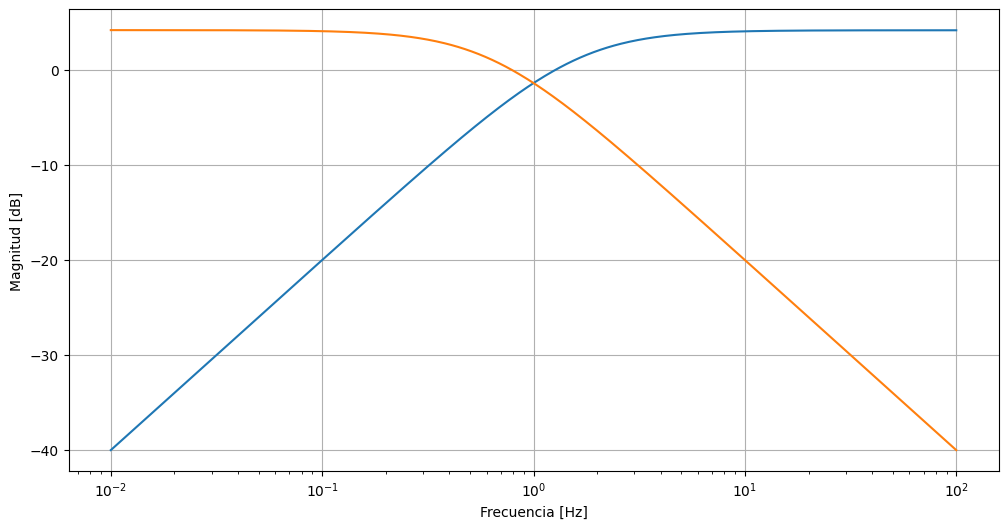

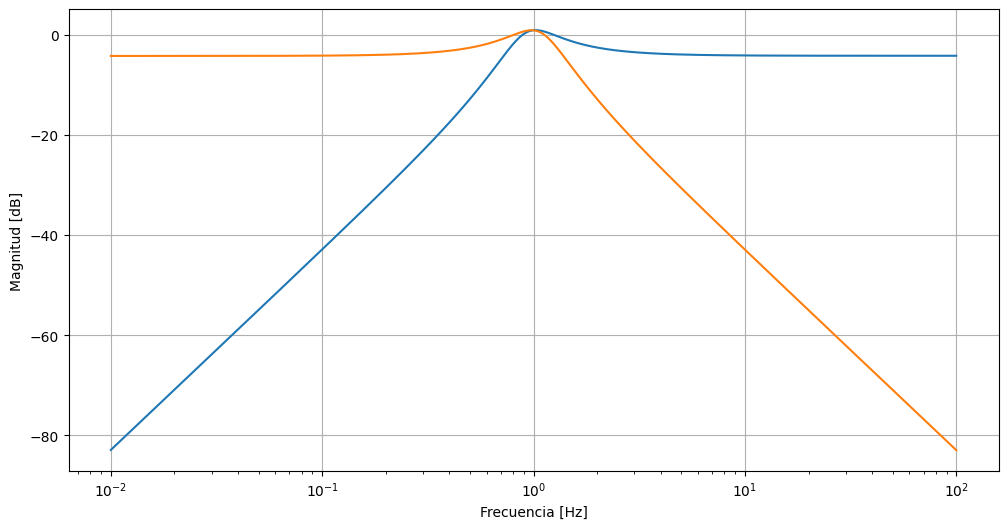

In [7]:
import scipy.signal as sp
import matplotlib.pyplot as plt
import numpy as np
import control

w = np.logspace(-2, 2, 500)

#%% 1ra etapa
num1_hp = [1.61, 0]
den1_hp = [1, 1.61]

num1_lp = [1]
den1_lp = [1, 0.62]

w_hp, h_hp = sp.freqs(num1_hp, den1_hp, w)
w_lp, h_lp = sp.freqs(num1_lp, den1_lp, w)

#Graficos de prueba
plt.figure(figsize=(12,6))
plt.semilogx(w_hp, 20*np.log10(abs(h_hp)))
plt.semilogx(w_lp, 20*np.log10(abs(h_lp)))

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid()
plt.show()

#%% 2da etapa

num2_hp = [0.62, 0, 0]
den2_hp = [1, 0.54, 0.87]

num2_lp = [0.71]
den2_lp = [1, 0.62, 1.15]

w2_lp, h2_lp = sp.freqs(num2_lp, den2_lp, w)
w2_hp, h2_hp = sp.freqs(num2_hp, den2_hp, w)

#graficos de prueba
plt.figure(figsize=(12,6))
plt.semilogx(w2_hp, 20*np.log10(abs(h2_hp)))
plt.semilogx(w2_lp, 20*np.log10(abs(h2_lp)))

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid()
plt.show()

<TransferFunction>: sys[53]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             0.9982 s^3
  --------------------------------
  s^3 + 2.15 s^2 + 1.739 s + 1.401


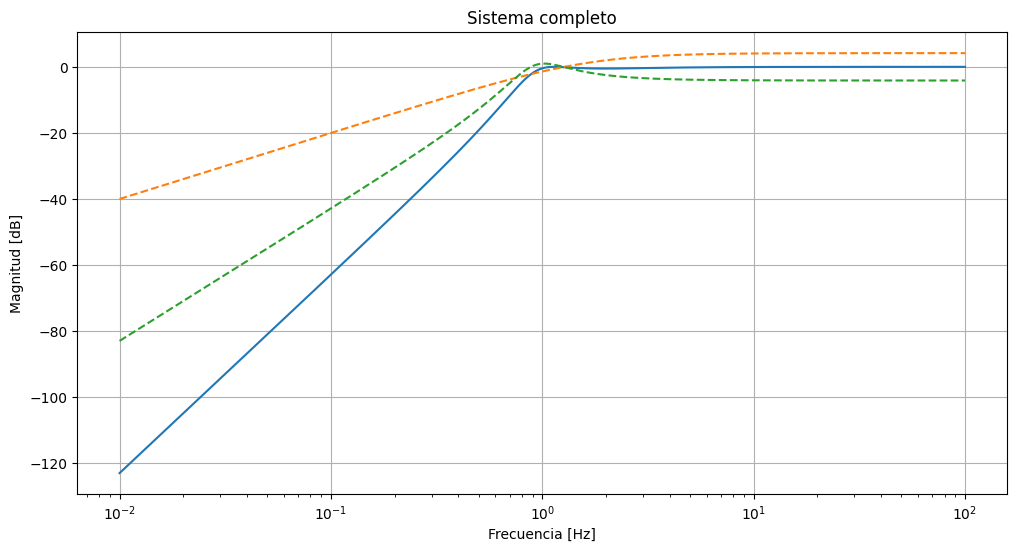

In [9]:
#%% sistema completo

#obtengo los sistemas y los pongo en cascada
sys1_hp = control.tf(num1_hp, den1_hp)
sys1_lp = control.tf(num1_lp, den1_lp)

sys2_hp = control.tf(num2_hp, den2_hp)
sys2_lp = control.tf(num2_lp, den2_lp)

syst_lp = control.series(sys1_lp, sys2_lp)
syst_hp = control.series(sys1_hp, sys2_hp)

print(syst_hp)
#%% GRAFICANDO EL SISTEMA COMPLETO
#obtengo las frecuencias para graficar
mag_lp, phase_lp, wt_lp = control.bode(syst_lp, w, plot=False)
mag_hp, phase_hp, wt_hp = control.bode(syst_hp, w, plot=False)

#test graficos todos los graficos
#graficos
plt.figure(figsize=(12,6))
plt.title("Sistema completo")

#high pass
plt.semilogx(wt_hp, 20*np.log10(abs(mag_hp)))
plt.semilogx(w_hp, 20*np.log10(abs(h_hp)), '--')
plt.semilogx(w2_hp, 20*np.log10(abs(h2_hp)), '--')

#low pass
#plt.semilogx(wt_lp, 20*np.log10(abs(mag_lp)))
#plt.semilogx(w_lp, 20*np.log10(abs(h_lp)), '--')
#plt.semilogx(w2_lp, 20*np.log10(abs(h2_lp)), '--')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid()
plt.show()

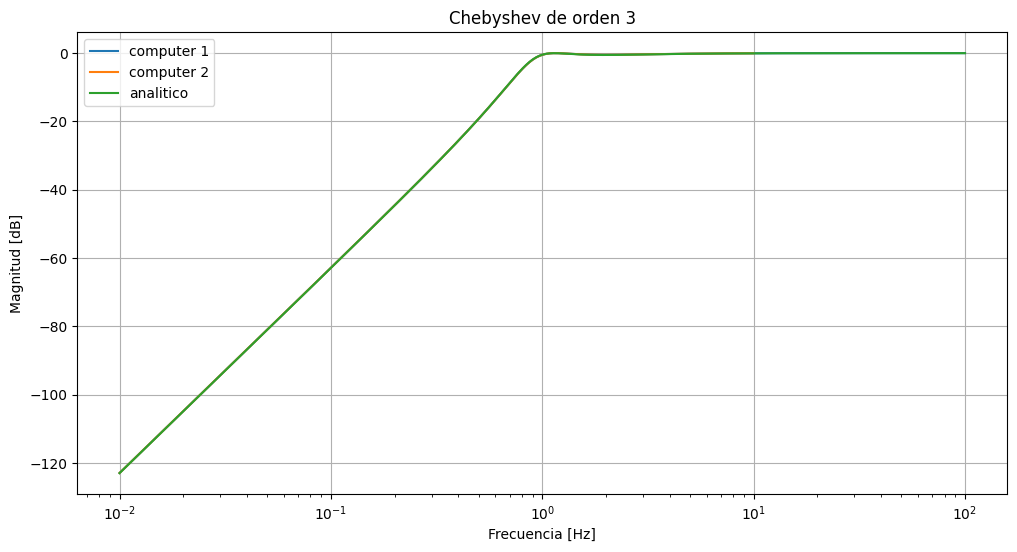

In [12]:
#%% Ahora comparo
#analitico vs python
n = 3       # orden del cheby
rp = 0.5    # db

#forma floja de realizarlo
num, den = sp.cheby1(3, rp, 1, btype='high', analog=True, output='ba')

w_cheby, h_cheby = sp.freqs(num, den, w)

'''
plt.figure(figsize=(12,6))
plt.title(f"Chebyshev de orden {n}")
plt.semilogx(w_cheby, 20*np.log10(abs(h_cheby)), label='computer')
plt.semilogx(wt_hp, 20*np.log10(abs(mag_hp)), label='analitico')

plt.legend()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid()
plt.show()
'''

#%% Forma pro de hacerlo
z, p, k = sp.cheb1ap(n, rp)
num_lp, den_lp = sp.zpk2tf(z, p, k)
num_hp, den_hp = sp.lp2hp(num_lp, den_lp)

w3_lp, h3_lp = sp.freqs(num_hp, den_hp)

plt.figure(figsize=(12,6))
plt.title(f"Chebyshev de orden {n}")
plt.semilogx(w_cheby, 20*np.log10(abs(h_cheby)), label='computer 1')
plt.semilogx(w3_lp, 20*np.log10(abs(h3_lp)), label='computer 2')
plt.semilogx(wt_hp, 20*np.log10(abs(mag_hp)), label='analitico')


plt.legend()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid()
plt.show()